<a href="https://colab.research.google.com/github/LeoFairley123/EMSC2010_W5_Assignment/blob/main/EMSC2010_Week5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010 Group Project template

## 1. Project Overview
Group name: Cloudy With a Chance of Stats

Project week: 5

Project title: Optimal BBQ Conditions on Xmas

Datasets used (name and source): Daily Maximum Temperature for Canberra (station number: 070339) and Ulladulla (station number: 069138) from the Bureau of Meteorology station records https://www.bom.gov.au/climate/averages/tables/cw_070339.shtml.

## 2. Roles and contributions

| Role | Primary | Deputy | Completed? | Notes |
| :--- | :--- | :--- | :--- | :--- |
| Github & integration | Sutton | Kimi | Yes| N/A|
| Data steward | Kimi | Cathy | Yes| N/A|
| Analysis / modelling | Cathy | Sameer | Yes| N/A|
| Visualisation / interpretation | Sameer | Leo | Yes| N/A|
| Narrative | Leo | Elena | Yes| N/A|
| Quality Control / Reproducibility  | Elena | Sutton | Partial| Deputy action required|


## 3. Deputy Interventions (if applicable)
Repeat text as required.

* Role affected: Quality Control

* Reason (e.g. missed deadline, absence, etc.): Missed Deadline

* Deputy action taken: Completed presubmission checklist

* Impact on workflow: Did not impact workflow as deputy just completed before submission which was their primary role

*N.B., this section should be factual, not judgemental.*

## 4. Pre-submission checklist
* Notebook runs from top to bottom.
* Datafiles are included in the GitHub repository. - Yes
* Commits include meaningful information. - Yes
* Each group member has included a brief reflection in the notebook. - Yes (minus Elena)
* Repository has been shared with the teaching team once your project is completed. - Yes

# Start your group project here

**Project Overview**

The group project began on Friday morning when we sat down to discuss potential climate related topics that could utilise a Monte Carlo technique. We decided to follow Dave's advice and think of a data set that could be easily found and analysed using a Monte Carlo technique first and then firm up our question afterwards. Our first thought was temperature data which we knew would be readily available from the BoM website. We then discussed a couple of different potential questions: comparing sites at different latitudes, looking at multiple weather stations from the same city and comparing different years. We settled on comparing Canberra to Ulladulla, two locations at similar latitudes (*~*$35^\circ$ South) and reasonably close longitudes (~$149^\circ$ & ~$150^\circ$ East). This would allow us to attribute difference in temperature between the locations to geographical features. Although further experimentation would be required to establish a causal link between any of these features and temperature differences, some of the likely causes for this temperature difference would be the ocean proximity of Ulladulla, the mountain range that seperates the two locations and the difference in altitude of ~600m. Looking at the datasets of the locations chosen, the Canberra dataset had the shorter temporal span, only going back to 1996. The 2026 dataset was also incomplete at the time of this project. This led us to use a reference period of 1996-2025 for comparison, examing one date across locations and years, which comfortably provided enough data points to to employ the Monte Carlo technique of bootstrapping to. We decided to put a fun spin on this problem and investigate whether the data suggested it would be better to stay in Canberra or head to the coast for a barbeque on Christmas Day. When asked "What is the best temperature for a barbeque?", ChatGPT suggested somewhere between $24^\circ\mathrm{C}$ and $27^\circ\mathrm{C}$ would be "Warm and summery without being exhausting, comfortable to sit, eat, socialise and have a lower risk of heat stress compared to very hot days".


In [ ]:
#import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

**Import data**

Data was found from the reliable source of the BoM, which Kimi downloaded and imported to the google colab for analysis. A key decision was choosing which specific weather stations to download data from, as it was necessary to search through a number to find two stations that recorded the same years over a long enough temporal span to have enough data points to bootstrap (~15). This could typically be deduced from the metadata, which led to multiple Canberra stations being discarded as well as Bateman's Bay, which was our initial coastal location. Once she had settled on two locations that had viable coverage (in theory) Kimi then had to go into the data sets and check whether the data record had any gaps. Funnily enough, the one gap across nearly 30 years of data and two locations was the date we had chosen to analyse (Christmas Day, 2001, Ulladulla). Kimi had a decision of whether to disregard this year across both locations, interpolate a value or disregard this year for just Ulladulla (which is what she ended up deciding).

This is a limitation because removing Christmas Day 2001 for Ulladulla but not Canberra creates an inconsistency in the temporal coverage of the datasets, reducing comparability between locations. The already small sample size is further reduced, which weakens the reliability of bootstrapping and increases uncertainty. Additionally, if the missing year was anomalous, its removal may introduce bias and distort estimates of variability and extremes. This last point is particularly relevant as, if 2001 was a particularly hot/cold year, this would have produced an anomalous value which would have shifted the mean and increased the variability for Canberra while being disregarded for Ulladulla. However, that year was not an abnormal year for Canberra, and so we concluded that this missing data point would not effect the outcome of the bootstrap significantly.

Daily Maximum Temperature data was obtained from the Bureau of Meteorology station records. Each value was taken for the 25th of December, the years 1996-2025 and from the weather stations located in Canberra (station number: 070339) and Ulladulla (station number: 069138). Years 1996-2025 were chosen due to the furthest year of data available from the Canberra station. Additionally, the 2001 value from the Ulladulla dataset is unavailable due to the value being missing from the station data.


In [43]:
path = 'https://raw.githubusercontent.com/LeoFairley123/EMSC2010_W5_Assignment/89cfb9a9ad0651c9547f61b23dc14f6c212666a0/Canberra%20and%20Ulladulla%20daily%20max%20temp%20data%20set.xlsx' # Corrected path to the raw Excel file
df = pd.read_excel(path, na_values=['n/a'])
df.columns = df.columns.str.strip().str.lower() # Clean column names by stripping whitespace and converting to lowercase
# Convert temperature columns to numeric, coercing any errors to NaN
df['canberra(ºc)'] = pd.to_numeric(df['canberra(ºc)'], errors='coerce')
df['ulladulla (ºc)'] = pd.to_numeric(df['ulladulla (ºc)'], errors='coerce')
df.head() #show the dataframe header information

,year,canberra(ºc),ulladulla (ºc)
0,1996,33.3,21.4
1,1997,32.6,24.0
2,1998,31.9,25.0
3,1999,21.7,24.1
4,2000,27.8,28.8


**Data Analyis**

To answer the question of which location would be best to have a barbeque on Christmas this year, we wanted to find the average temperatures but also the range and probability/confidence that coming years would be within this range. Bootstrapping was chosen as a technique that could provide us a more reliable distribution curve as well as estimate the variability and uncertainty for each location. Cathy bootstrapped the imported data by running 100 000 simulations. Deciding how many times to run the simulation required considering a trade-off between useing computer processing power/time and accuracy/effectiveness of the bootstrap. 100 000 simulations was decided as a good comprimise as it would produce a smooth distribution. This data could then be used to produce a distribution curve revealing what temperatures the two locations would typically see on Christmas Day.

In [ ]:
Canberra = np.random.choice(df['canberra(ºC)'], size=(len(df), 100000), replace=True)
#Create 100000 simulated versions of Canberra temperature dataset by randomly resampling it (with replacement)
#len(df) is the length of Canberra data (which is 30)
print(Canberra)

[[19.1 21.  31.9 ... 18.6 26.3 18.6]
 [23.9 21.7 21.7 ... 27.8 20.5 21. ]
 [20.5 23.9 32.2 ... 28.  31.1 32.8]
 ...
 [21.  20.5 24.8 ... 29.  18.6 21.7]
 [18.6 21.7 28.  ... 21.3 26.3 32.8]
 [29.8 27.3 32.2 ... 21.3 28.  27.3]]


In [ ]:
Ulladulla = np.random.choice(df['ulladulla (ºC)'].dropna(), size=(len(df), 100000), replace=True)
#Create 100000 simulated versions of Ulladulla temperature dataset by randomly resampling it (with replacement)
#len(X) is the length of Ulladulla data (which is 30), repeat 100000 times
print(Ulladulla)

[[20.7 20.7 25.4 ... 21.7 25.  27.5]
 [28.8 23.6 25.7 ... 20.2 20.7 25.7]
 [27.5 23.4 21.7 ... 20.9 20.2 28.8]
 ...
 [19.9 19.9 23.6 ... 25.  23.4 20.7]
 [27.8 23.6 24.7 ... 25.7 24.4 27.5]
 [20.7 20.2 21.4 ... 20.7 22.3 24.4]]


In [ ]:
bar_Canberra = np.mean(Canberra,axis=0)
bar_Ulladulla = np.mean(Ulladulla,axis=0)
#Take the average of each column in the Canberra and Ulladulla random choice dataset

In [ ]:
print(bar_Canberra)
print(bar_Ulladulla)

[26.43       25.7        26.60666667 ... 25.25       26.70333333
 25.91666667]
[23.59333333 23.23666667 22.88333333 ... 22.74666667 22.49333333
 22.94666667]


**Visualisation**

After bootstrapping the data, Sameer had to decide the best way to display these results for easy visualisation and interpretation. A bar graph allowed for an accessible way to view the new, smoother temperature distributions. Sameer had to decide on a bin size to divide the data up into that was small enough to be meanigful but large enough to plot cleanly. The rule of thumb of using the square root of the sample size worked perfectly here. Sameer also plotted the data using red and blue distribution curves on the same graph, allowing for direct comparison between locations and keeping it accessible for colourblind viewers. This was probably the key decision regarding visualisation, and is a superior choice to plotting the two locations on seperate graphs with potentially different scales as this would have made comparison much harder.

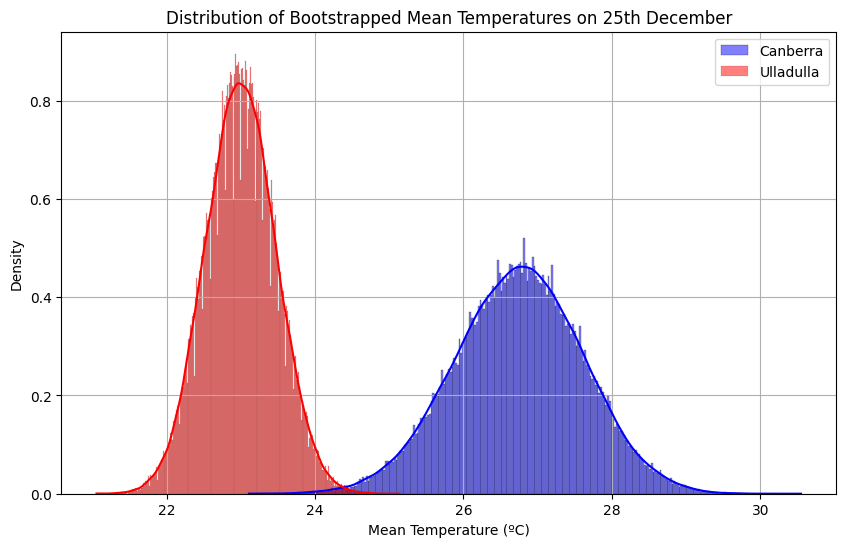

In [ ]:
import seaborn as sns # Import seaborn for enhanced visualizations.
import matplotlib.pyplot as plt # Import matplotlib.pyplot for plotting.

bar_Canberra_cleaned = bar_Canberra[~np.isnan(bar_Canberra)] # Remove NaN values from Canberra's bootstrapped means.
bar_Ulladulla_cleaned = bar_Ulladulla[~np.isnan(bar_Ulladulla)] # Remove NaN values from Ulladulla's bootstrapped means.

plt.figure(figsize=(10, 6)) # Create a new figure with a specified size.

num_bins = int(np.sqrt(100000)) # Calculate the number of bins based on the square root of samples.

sns.histplot(bar_Canberra_cleaned, color='blue', label='Canberra', kde=True, stat='density', alpha=0.5, bins=num_bins) # Plot histogram for Canberra's bootstrapped means.
sns.histplot(bar_Ulladulla_cleaned, color='red', label='Ulladulla', kde=True, stat='density', alpha=0.5, bins=num_bins) # Plot histogram for Ulladulla's bootstrapped means.

plt.title('Distribution of Bootstrapped Mean Temperatures on 25th December') # Add a title to the plot.
plt.xlabel('Mean Temperature (ºC)') # Label the x-axis.
plt.ylabel('Density') # Label the y-axis.
plt.legend() # Display the legend.
plt.grid(True) # Add a grid to the plot.
plt.show() # Show the generated plot.

In [ ]:
import numpy as np
std_canberra = np.std(bar_Canberra_cleaned)
std_ulladulla = np.std(bar_Ulladulla_cleaned)
print(f"Standard Deviation of Bootstrapped Canberra Means: {std_canberra:.2f} ºC")
print(f"Standard Deviation of Bootstrapped Ulladulla Means: {std_ulladulla:.2f} ºC")

Standard Deviation of Bootstrapped Canberra Means: 0.86 ºC
Standard Deviation of Bootstrapped Ulladulla Means: 0.47 ºC


In [ ]:
import numpy as np
# Define the temperature range for the confidence interval
lower_bound = 24
upper_bound = 27

# Calculate the proportion of Canberra's bootstrapped means within the range
canberra_in_range = ((bar_Canberra_cleaned >= lower_bound) & (bar_Canberra_cleaned <= upper_bound)).mean()
print(f"Proportion of Canberra's bootstrapped means within {lower_bound}-{upper_bound}ºC: {canberra_in_range:.2%}")

# Calculate the proportion of Ulladulla's bootstrapped means within the range
ulladulla_in_range = ((bar_Ulladulla_cleaned >= lower_bound) & (bar_Ulladulla_cleaned <= upper_bound)).mean()
print(f"Proportion of Ulladulla's bootstrapped means within {lower_bound}-{upper_bound}ºC: {ulladulla_in_range:.2%}")

Proportion of Canberra's bootstrapped means within 24-27ºC: 61.22%
Proportion of Ulladulla's bootstrapped means within 24-27ºC: 1.80%


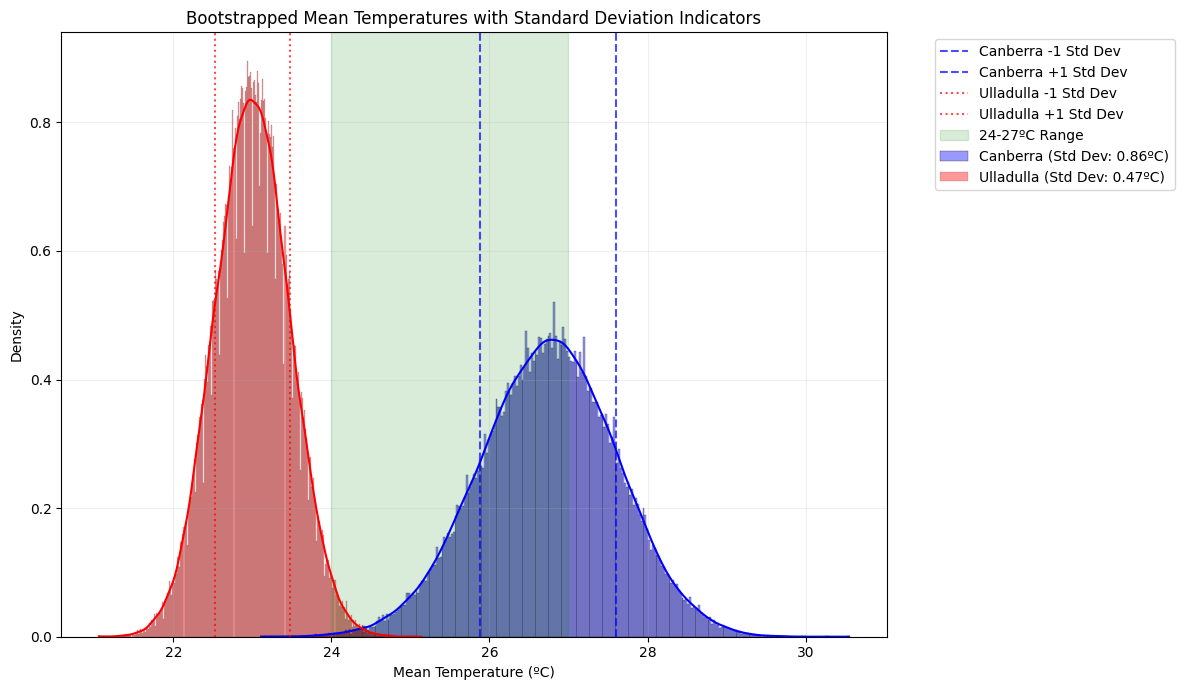

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Re-plot the distributions with the specified confidence interval and standard deviations highlighted
plt.figure(figsize=(12, 7))

num_bins = int(np.sqrt(100000))

# Calculate means for plotting vertical lines
mean_canberra = np.mean(bar_Canberra_cleaned)
mean_ulladulla = np.mean(bar_Ulladulla_cleaned)

# Plot histograms
sns.histplot(bar_Canberra_cleaned, color='blue', label=f'Canberra (Std Dev: {std_canberra:.2f}ºC)', kde=True, stat='density', alpha=0.4, bins=num_bins)
sns.histplot(bar_Ulladulla_cleaned, color='red', label=f'Ulladulla (Std Dev: {std_ulladulla:.2f}ºC)', kde=True, stat='density', alpha=0.4, bins=num_bins)

# Plot lines for Standard Deviation (Mean +/- 1 Std Dev)
plt.axvline(mean_canberra - std_canberra, color='blue', linestyle='--', alpha=0.7, label='Canberra -1 Std Dev')
plt.axvline(mean_canberra + std_canberra, color='blue', linestyle='--', alpha=0.7, label='Canberra +1 Std Dev')

plt.axvline(mean_ulladulla - std_ulladulla, color='red', linestyle=':', alpha=0.7, label='Ulladulla -1 Std Dev')
plt.axvline(mean_ulladulla + std_ulladulla, color='red', linestyle=':', alpha=0.7, label='Ulladulla +1 Std Dev')

# Highlight the 24-27 degree Celsius range
plt.axvspan(lower_bound, upper_bound, color='green', alpha=0.15, label=f'{lower_bound}-{upper_bound}ºC Range')

plt.title('Bootstrapped Mean Temperatures with Standard Deviation Indicators')
plt.xlabel('Mean Temperature (ºC)')
plt.ylabel('Density')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which='both', linestyle='-', alpha=0.2)
plt.tight_layout()
plt.show()

**Interpretation**

 The bootstrapped mean temperature of Canberra is **26.74 °C**, which aligns closely with the ideal temperature of **27 °C**. In contrast, Ulladulla’s mean is significantly lower at approximately **23 °C**. From a scientific perspective, Ulladulla shows a consistent cold bias relative to the preferred barbecue conditions.

Canberra’s standard deviation (**0.86 °C**) is nearly double that of Ulladulla (**0.48 °C**). This is visually evident from the wider spread of the blue dashed lines compared to the tightly clustered red dotted lines.

This confirms that Canberra’s inland climate is more sensitive to inter-annual atmospheric variations. Ulladulla’s narrow distribution highlights the *maritime effect*, where the ocean’s high thermal inertia acts as a stabiliser, suppressing temperature extremes.

This can be attributed to the effects of the coastal climate. The high heat capacity of the ocean moderates temperature change, slowing heating and cooling. Ulladulla air flow is also dominated by ocean breezes. This keeps temperature more consistent year to year and reduces the impact of extremely hot days. On the other hand, Canberra's inland location means that the ground can warm or cool much faster, and it is subject to both cooler southerly winds or hot air from inland. These factors make Canberra's climate much more variable and lead to the wider and warmer distribution evident on the graph.

Even though Canberra is more variable, its distribution is positioned more effectively over the target range. Approximately **61.35%** of Canberra’s bootstrapped means fall within **24–27 °C**, making it statistically the “safer” option for these specific bbq conditions.

Ulladulla is consistently cooler, with only approximately **1.85%** of its simulated means reaching the **24 °C** threshold. In fact, its **+1 standard deviation** line barely reaches the beginning of the green target zone.

Since the optimal conditions for barbie, according to ChatGPT, are between **24 °C and 27 °C**, Canberra is the ideal candidate for a Christmas barb.

Considering skills learnt in later weeks of the course, an appropriate extension for this project would have been to perform a regression on the data. Our current bootstrap analysis gives us a distribution and mean of historical data. We then assume that these conditions are not being influenced by any forcings and use that analysis to generate predictions of future conditions. In reality, climate change is resulting in locations changing their mean over time and applying this trend to extrapolate our boostrapped data (by applying the standard deviations found from historical data to extroplated future points) would likely allow for a more accurate prediction of future BBQ conditions at Christmas.

Ultimately, it is tough to draw conclusions about the influential climate factors based on one measurement (max temp), and both Canberra and Ulladulla will hopefully have great BBQ conditions this Chrissy.

# **Individual Reflections**

**Sutton**

This week I had the role of Github repository and integration lead, requiring me to be the first to do the intial essential work to begin the assignment. The creation of the Github repository was straightforward, but when needing to share the Colab notebook I made an error in the permissions I selected for colaborators. This was quickly remedied after Cathy gave me a heads up and I reshared the notebook with correct editorial permissions. To ensure all work that had been done was saved and comitted to github I also had to undertake some project management and chase up work that was not completed by set deadlines.
From undertaking this role I have learnt to correctly create Github repositories and use Google Colab to enable group work, project management skills by ensuring all set tasks have been completed by either the primary or deputy and chasing up work that was not compelted by the deadlines.

**Kimi**

The data steward role required me to obtain suitable data for an agreed upon topic. The data was relatively easy to obtain, due to the BOM having open access for all their station data. All available daily maximum temperatures were downloaded for both stations in the form of an excel sheet, these values were then obtained and placed in a seperate excel sheet by station and year for ease of access for the analysis/modelling role. From this role, I had learnt skills in relation to excel and assessing suitable data. Overall, a valuable learning experience.

**Cathy**

To analyse the data, I used a similar method to what was done in class to bootstrap the temperature in Canberra and Ulladulla. The numpy function 'random choice' was used to resample the data 100000 times. Simulating this resampling over many times allowed for each simulation to be averaged, which will help produce a normal distribution curve, revealing a temperature range that Canberra and Ulladulla would typically see on Christmas day. This solidified my understanding on how to use the bootstraping method to analyse a set of data.

**Sameer**

To visualize the data I plotted the bootstrapped mean temperatures from Canberra and Uladulla on December 25th.The histograms were overlaid with Kernel Density Estimates (KDE), which shows the spread and central tendency of the simulated average temperatures from both locations.This visualization helps in understanding the typical temperature range and variability for each city based on the resampled data.We are using Kernel Density Estimation (KDE) in the histogram to provide a smooth, continuous representation of the data's distribution.

The interpretation from the plot is:

**Canberra:** Generally warmer on Christmas Day, with bootstrapped means peaking around 26-28°C and variations often in the high 20s or low 30s. Ideal for those who prefer hot barbecue conditions.

**Ulladulla:** Tends to be milder, with bootstrapped means peaking around 22-24°C and  temperatures typically in the low to mid-20s. A better choice for those who prefer more moderate barbecue weather.

**Leo**

I helped create the question once we had chosen the broader topic of location based maximum temperature comparison. I then went through and wrote explanations in the markdown boxes of each step that was completed en route to conveying the results. While doing this, I fixed a couple of spelling errors and missing annotations in completed work and ensured that everything was in the correct order to ensure a logical flow of question then analysis then results for the viewer. I noticed that we had missed an integral purpose of bootstrapping in using it to draw a conclusion about the uncertainty/variability of the data and brought this to the attention of the team. Finally, I explained key decsions that were made during the project and any limitations associated with these decisions. This process forced me to think through the decisions that other group members made, which will prepare me for when I undertake those roles and face similar decisions. I also learnt that despite the appeal of having a barbeque at the ocean on Christmas Day, if you are chasing the ideal temperature according to ChatGPT, Canberra is the superior location.

**Elena**

I had the final role, Quality Control & Reproducibility, which was made easy by the hard work of my team members before me. I was around to answer clarifying questions by members of my group, and check if the code was working as it was being written, before my final checks before submission. I did not hear much from the data steward, Kimi, before I checked her data myself, but it was all clearly laid out where to find it, and the spreadsheet attached to the GitHub was very easy to read. I ran each cell individually before realising there was a 'Run all' button, but I appreciated that I got a chance to see what each individual cell did before checking that it all ran together. A few spelling errors were corrected, but overall, the work is of high quality & easily reproducible.